**Oasis Infobyte - OIBSIP - Data Science**

**Author : Gauri Pardhi**

**TASK 2 : Car Price Prediction**

**Objective**

**Install libraries**

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


**2. Import libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

3. Load dataset

In [3]:
df = pd.read_csv("car_price_prediction_.csv")

In [4]:
print(df.head())

   Car ID  Brand  Year  Engine Size Fuel Type Transmission  Mileage Condition  \
0       1  Tesla  2016          2.3    Petrol       Manual   114832       New   
1       2    BMW  2018          4.4  Electric       Manual   143190      Used   
2       3   Audi  2013          4.5  Electric       Manual   181601       New   
3       4  Tesla  2011          4.1    Diesel    Automatic    68682       New   
4       5   Ford  2009          2.6    Diesel       Manual   223009  Like New   

      Price     Model  
0  26613.92   Model X  
1  14679.61  5 Series  
2  44402.61        A4  
3  86374.33   Model Y  
4  73577.10   Mustang  


In [5]:
print(df.shape)

(2500, 10)


In [6]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   str    
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   str    
 5   Transmission  2500 non-null   str    
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   str    
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   str    
dtypes: float64(2), int64(3), str(5)
memory usage: 266.2 KB
None


4: Check Missing Values

In [7]:
print(df.isnull().sum())

Car ID          0
Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
Model           0
dtype: int64


5: Data Visualization

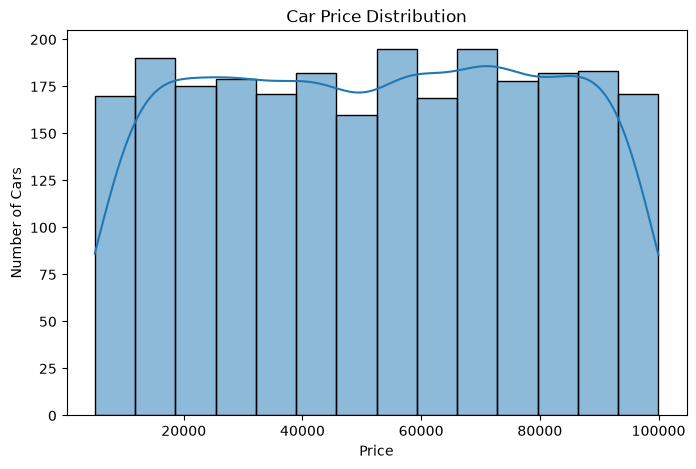

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df['Price'], kde=True)

plt.xlabel("Price")
plt.ylabel("Number of Cars")

plt.title("Car Price Distribution")

plt.show()

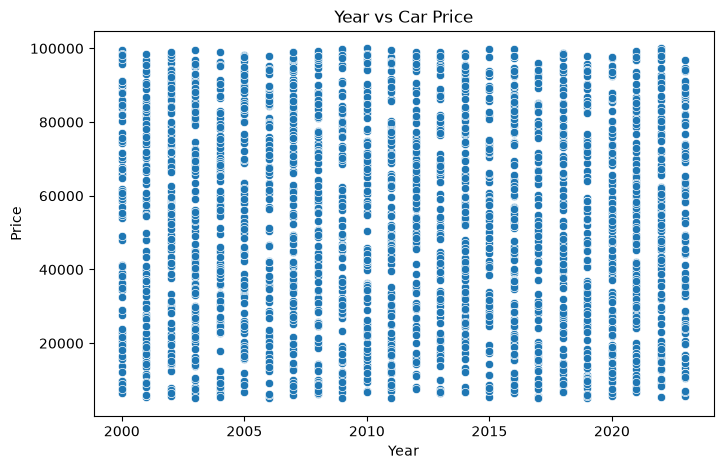

In [9]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Year",
    y="Price",
    data=df
)

plt.title("Year vs Car Price")

plt.show()

6: Convert Categorical Data

In [10]:
df = pd.get_dummies(
    df,
    columns=[ 'Fuel Type', 'Transmission', 'Condition', 'Model'],
    drop_first=True
)

print(df.head())

   Car ID  Brand  Year  Engine Size  Mileage     Price  Fuel Type_Electric  \
0       1  Tesla  2016          2.3   114832  26613.92               False   
1       2    BMW  2018          4.4   143190  14679.61                True   
2       3   Audi  2013          4.5   181601  44402.61                True   
3       4  Tesla  2011          4.1    68682  86374.33               False   
4       5   Ford  2009          2.6   223009  73577.10               False   

   Fuel Type_Hybrid  Fuel Type_Petrol  Transmission_Manual  ...  \
0             False              True                 True  ...   
1             False             False                 True  ...   
2             False             False                 True  ...   
3             False             False                False  ...   
4             False             False                 True  ...   

   Model_Model S  Model_Model X  Model_Model Y  Model_Mustang  Model_Prius  \
0          False           True          False    

7: Car ID remove 

In [11]:
if 'Car ID' in df.columns:
    df = df.drop('Car ID', axis=1)

print(df.columns)

Index(['Brand', 'Year', 'Engine Size', 'Mileage', 'Price',
       'Fuel Type_Electric', 'Fuel Type_Hybrid', 'Fuel Type_Petrol',
       'Transmission_Manual', 'Condition_New', 'Condition_Used',
       'Model_5 Series', 'Model_A3', 'Model_A4', 'Model_Accord',
       'Model_C-Class', 'Model_CR-V', 'Model_Camry', 'Model_Civic',
       'Model_Corolla', 'Model_E-Class', 'Model_Explorer', 'Model_Fiesta',
       'Model_Fit', 'Model_Focus', 'Model_GLA', 'Model_GLC', 'Model_Model 3',
       'Model_Model S', 'Model_Model X', 'Model_Model Y', 'Model_Mustang',
       'Model_Prius', 'Model_Q5', 'Model_Q7', 'Model_RAV4', 'Model_X3',
       'Model_X5'],
      dtype='str')


8: Features and Target

In [12]:
X = df.drop('Price', axis=1)
Y = df['Price']

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (2500, 37)
Y shape: (2500,)


9: Split Dataset

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=2
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2000, 37)
Testing data: (500, 37)


10: Train Model

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Load dataset
df = pd.read_csv("car_price_prediction_.csv")

# Convert categorical columns into numbers
df = pd.get_dummies(
    df,
    columns=['Brand', 'Fuel Type', 'Transmission', 'Condition', 'Model'],
    drop_first=True
)

# Remove Car ID
if 'Car ID' in df.columns:
    df = df.drop('Car ID', axis=1)

# Features and Target
X = df.drop('Price', axis=1)
Y = df['Price']

# Split data
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=2
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

# Create model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=2
)

# Train model
model.fit(X_train, Y_train)

print("Model trained successfully!")

Training data: (2000, 42)
Testing data: (500, 42)
Model trained successfully!


11: prediction

In [15]:
prediction = model.predict(X_test)

print(prediction)

[49939.2371 43188.6187 36774.2789 55437.7956 52514.4537 54821.8468
 46308.6596 55332.5252 51274.4199 53644.1809 52324.4899 53165.4295
 56148.1824 43713.9306 50398.0301 44377.3873 61916.4176 50769.3156
 40682.838  38538.0055 52969.4646 56547.9962 68646.5141 57229.1187
 37063.4548 41694.7004 46507.4815 65141.1503 48329.0817 63890.4419
 35236.2903 51947.8455 47133.7245 47578.9286 51033.9992 50731.2543
 53601.6742 65040.5227 49642.7926 53824.6434 65971.9068 40319.893
 61297.1904 58952.9166 48247.804  46490.9954 58625.4138 42665.0249
 52977.1065 47683.7343 55814.0791 54491.3429 49826.3396 52583.8766
 60261.2567 70178.5594 56397.2289 41706.0031 51952.1724 56096.2741
 57768.3639 44024.2323 68260.1663 51471.4798 51488.1014 61524.6064
 47879.8533 48388.8443 56061.9205 61827.6113 58897.8498 54168.3961
 53031.7042 43729.0305 42446.9193 46756.7026 50334.5464 50748.1625
 49095.5245 49235.993  54510.6537 46045.7287 64796.4845 56539.7643
 43059.4322 52879.6737 48408.1919 36767.3722 48501.86   64512.2

12: Accuracy

In [16]:
import numpy as np

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(Y_test, prediction)
mse = mean_squared_error(Y_test, prediction)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, prediction)

print("MAE =", mae)
print("MSE =", mse)
print("RMSE =", rmse)
print("R2 Score =", r2)

MAE = 23925.6173776
MSE = 770123266.7518328
RMSE = 27751.094874830305
R2 Score = -0.0444275323346881


13: Actual VS Predicted Graph

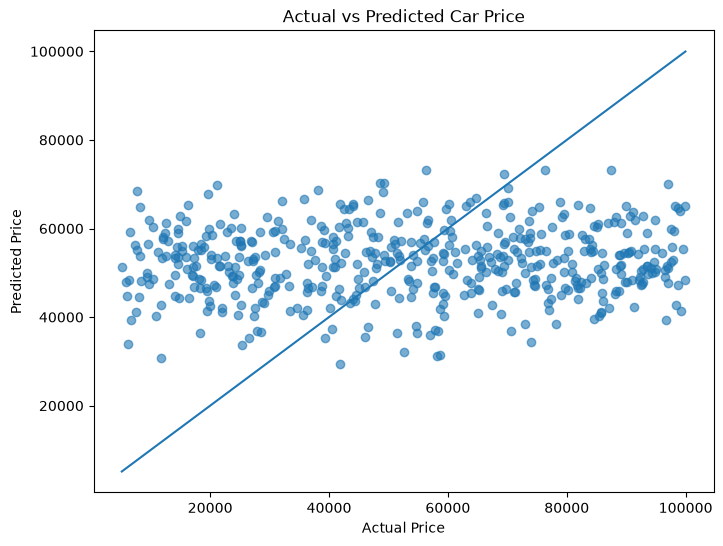

In [18]:
# STEP 13: ACTUAL VS PREDICTED GRAPH

import matplotlib.pyplot as plt
import numpy as np

# Make prediction again
prediction = model.predict(X_test)

# Convert to numpy arrays
actual = np.array(Y_test)
predicted = np.array(prediction)

# Plot
plt.figure(figsize=(8, 6))

plt.scatter(actual, predicted, alpha=0.6)

# Perfect prediction line
minimum = min(actual.min(), predicted.min())
maximum = max(actual.max(), predicted.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum]
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Price")

plt.show()